# 论文详解
## 基本信息

| 项目       | 内容                                                                           |
| -------- | ---------------------------------------------------------------------------- |
| **标题**   | FIPO: Eliciting Deep Reasoning with Future-KL Influenced Policy Optimization |
| **作者**   | Chiyu Ma 等                                                                   |
| **发表**   | arXiv, 2026年3月20日（v3更新于3月31日）                                                |
| **代码**   | 基于 VeRL 框架，完全开源训练代码与配置                                                       |
| **核心目标** | <font color='red'>解决 GRPO 类算法中**粗粒度信用分配**导致的推理瓶颈，激发模型的深度推理能力  </font>                                 |

## 研究背景与动机
近年来，OpenAI o 系列、DeepSeek-R1 等模型通过测试时扩展（test-time scaling）
- 即在推理阶段分配更多计算资源、生成更长的思维链（Chain-of-Thought, CoT）
- 在数学竞赛和代码任务上取得了突破性进展。这些进展很大程度上依赖于基于可验证奖励的强化学习（RLVR）。

然而，当前主流的 GRPO（Group Relative Policy Optimization）及其变体（如 DAPO）**虽然训练效率高，但存在根本性缺陷：**
  - <font color='red'>粗粒度信用分配问题</font>：
    - GRPO 使**用基于结果的奖励**（Outcome Reward Model, ORM），<font color='blue'>将同一个轨迹中所有 token 的优势值（advantage）均匀分配。</font>
      - <font color='green'>将同一个轨迹中所有 token 的优势值（advantage）均匀分配这意味着一个关键逻辑转折 token 和一个无关紧要的填充 token 获得完全相同的梯度信号，无法区分"关键推理步骤"和"普通 token"。</font>
  
**这一缺陷导致模型在训练后期陷入长度-性能瓶颈（length-performance plateau）：**
  - <font color='green'>推理长度停滞在约 4,000 tokens，性能也随之封顶，无法进一步激发更深层次的自我反思和验证行为。</font>

## 核心方法：FIPO
- FIPO（Future-KL Influenced Policy Optimization）的核心思想是：
  - <font color='green'>将稀疏的结果奖励</font>-->转化为--><font color='red'>密集的 token 级监督信号</font>，<font color='blue'>**通过衡量每个 token 对其后续轨迹的因果影响力来重新加权优势值。**</font>
  
### 3.1 概率偏移（Probability Shift）：Δlog p
FIPO 将 token 级别的概率偏移作为信用分配的原子单位：
    
$Δlog p_t = log\pi_\theta(o_t \| q,o_{<t}) - log\pi_{θ_{old}}(o_t \| q,o_{<t})$


- $Δlog p_t$ <font color='red'>\> 0</font>：当前策略<font color='red'>增强</font>了这个 token 的生成概率，说明训练正在强化该推理步骤
- $Δlog p_t$ <font color='red'>< 0</font>：当前策略在<font color='red'>抑制</font>这个 token，说明模型在主动降低该 token 的权重
- <font color='blue'>这一指标捕捉了策略的瞬时漂移方向。</font>

### 3.2 Future-KL 估计
<font color='green'>推理是一个序列过程，单个 token 的真正重要性取决于它引发的后续轨迹。</font>因此，FIPO 定义 Future-KL 为从当前步骤到序列末尾的累积有符号概率偏移：

$FutureKL_t = \sum^T_{k=t}Δlogp_k$

这<font color='green'>等价于</font>后续序列的联合概率分布的对数似然比，**可以解释为限制在未来时间窗口内的 KL 散度样本估计。**

- FutureKL_t > 0：<font color='green'>更新后的策略整体强化了由该 token 引发的后续轨迹，说明这个 token 是后续推理链的稳定锚点</font>
- FutureKL_t < 0：策略在集体抑制该 token 之后的未来 token，说明这条路径正在被优化过程弱化

为了限制有效视野并优先关注邻近信号，FIPO 还引入了软衰减窗口（soft decay window），<font color='green'>对远处的 token 施加指数衰减。</font>

### 3.3 Future-KL 重加权优势（带裁剪）

FIPO 将标准优势估计  $\hat{A_t}$通过 Future-KL 进行调制：

- $f_t = clip(exp(FutureKL_t),1 - \epsilon_{f_{low}},1+\epsilon_{high})$

- $ \tilde{A}_t = \hat{A}_t \cdot f_t $

#### 关键机制解读：

| FutureKL\_t 状态 | f\_t 范围 | 效果                                              |
| -------------- | ------- | ----------------------------------------------- |
| > 0（**强化未来**）      | > 1     | 放大梯度信号：正向优势被增强以鼓励该锚点 token；负向优势被更严厉惩罚           |
| < 0（**抑制未来**）      | < 1     | <font color='red'>衰减更新</font>：降低"成功序列中的有害 token"的奖励，减轻"失败序列中的好 token"的惩罚 |

为防止数值不稳定，$f_t$ 被裁剪到可控区间（如 [1.0, 1.2]），并配合安全阈值过滤极端影响权重。



In [5]:
from IPython.display import Image

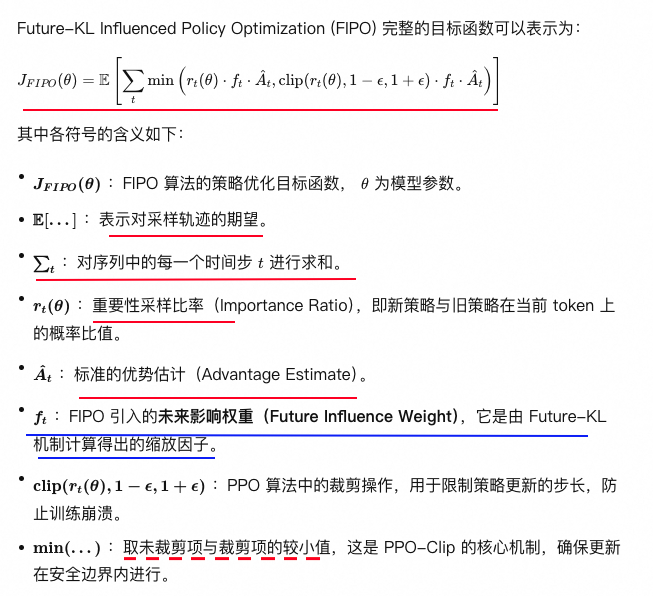

In [14]:
Image(filename='./Image/fipo.png')

## 实验设置
###  训练配置

| 配置项                 | 详情                                       |
| ------------------- | ---------------------------------------- |
| **基础模型**            | Qwen2.5-32B-Base（无长 CoT 合成数据预训练）         |
| **训练框架**            | VeRL                                     |
| **训练数据**            | DAPO-17K（公开数据集，确保严格对照）                   |
| **全局批次**            | 512 prompts × 16 responses = 8,192 样本/迭代 |
| **Mini-batch**      | 1,024 样本（64 prompts），每迭代 8 次梯度更新         |
| **学习率**             | 1×10⁻⁶，常数调度 + <font color='red'>10 步 warmup</font>                |
| **最大响应长度**          | 20,480 tokens，超长惩罚阈值 16,384              |
| **Future-KL 衰减率 τ** | 32                                       |
| **Future-KL 裁剪**    | \[1.0, 1.2]                              |
| **安全阈值**            | 10.0                                     |

注：7B 模型 pilot 实验中，group size 提升至 32，优势裁剪阈值设为 3.0 以稳定训练。

### 评估基准
- 主要基准：AIME 2024
- 补充基准：AIME 2025
- 评估协议：重复 32 次，报告 Pass@1 平均值
- 推理参数：temperature=1.0, top-p=0.7



## 主要实验结果
###  性能突破

| 模型/方法                     | AIME 2024 Pass\@1 |
| ------------------------- | ----------------- |
| DAPO（复现基线）                | 50.0%             |
| DeepSeek-R1-Zero-Math-32B | ~47.0%            |
| o1-mini                   | ~56.0%            |
| **FIPO（峰值）**              | **58.0%**         |
| **FIPO（收敛）**              | **~56.0%**        |

FIPO 不仅超越了同类的纯 RL 基线，还超过了 o1-mini。

### 推理长度的持续扩展
这是 FIPO 最引人注目的发现：

| 指标        | DAPO              | FIPO                      |
| --------- | ----------------- | ------------------------- |
| 平均 CoT 长度 | ~4,000 tokens（停滞） | **> 10,000 tokens（持续增长）** |
| 中位数长度     | ~4,000            | 从 200 逐步增长至 > 10,000      |

<font color='red'>FIPO 成功打破了 DAPO 的"长度-性能瓶颈"，使模型从约 4,000 tokens 的浅层推理进入超过 10,000 tokens 的深度推理 regime。</font>

## 深入分析
###  推理行为的四阶段演化
论文通过定性案例分析，揭示了 FIPO 训练过程中模型推理策略的渐进式演化：

| 阶段                   | 特征                                            | 长度                |
| -------------------- | --------------------------------------------- | ----------------- |
| **Stage 1: 表面规划**    | 生成模板化的解题大纲，但无实际数学推导，常导致幻觉结论                   | 很短                |
| **Stage 2: 线性执行**    | 能准确执行标准 CoT 到达正确答案，但"单遍"逻辑，<font color='red'>找到第一个结果即终止 </font>        | ~4,000（DAPO 收敛于此） |
| **Stage 3: 涌现自我反思**  | 利用扩展的 token 预算进行自发反思，主动用替代方法（如从代数切换到几何解释）交叉验证 | 持续增长              |
| **Stage 4: 系统性深度推理** | 进入"重计算"策略，进行多轮符号重推导和细粒度算术验证，将长度视为确保性能的关键资源    | > 10,000          |

<font color='blue'>这种自发涌现的自我验证行为与 OpenAI o 系列和 DeepSeek-R1 的推理时扩展行为高度一致。</font>

### 训练动态对比
与 DAPO 相比，FIPO 展现出更优的优化特性：
- Policy KL 散度：
  - FIPO 呈现稳定、结构化的增长，反映渐进式策略迁移；
  - DAPO 波动剧烈
- 梯度范数：
  - FIPO 保持低且稳定的梯度范数，<font color='red'>基于细粒度更新</font>；
  - DAPO 频繁出现剧烈尖峰
- 策略熵：
  - FIPO 的<font color='red'>熵平滑持续上升，表明稳定探索更广泛的推理空间</font>；
  - DAPO 的熵充满噪声振荡
这些指标表明 FIPO 在实现显著策略演化的同时，保持了数值稳定性。

###  长度与性能的强相关性
- FIPO 训练中，响应长度的所有分位数（Min、Q25、Mean、Median、Q75）同步稳定上升，表明这不是由少数异常值驱动的，而是整个分布的系统性迁移。
- 更重要的是，准确率与响应长度之间存在持续的正相关关系——FIPO 成功将增加的序列长度转化为真正的推理深度

## 局限性与未来工作
论文坦诚地指出了以下局限：
- 计算成本：
  - 推理长度超过 10,000 tokens 后，训练和推理开销显著增加。作者认为应先"激发"高质量长推理能力，再优化效率。
- 任务泛化：
  - 目前仅在数学推理基准上验证。虽然数学是深度推理的严格代理，但其他领域（如代码、开放域推理）的泛化性有待探索。
- 数据规模：
  - 为与 DAPO 公平对比，仅使用了 DAPO-17K 数据集，未探索更大规模或更高质量数据下的扩展性。
- 领域特异性：
  - 在数学上超越 o1-mini 的优势是领域特定的，不预期能泛化到非数学领域。

# 对数概率偏移量 Δlogpk

在 FIPO（Future-KL Influenced Policy Optimization） 算法中，对数概率偏移量 Δlogp_k是一个核心概念，
- 它衡量的是模型在强化学习训练过程中，某个未来 token k 的生成概率相对于旧策略的<font color='blue'>变化方向</font>和<font color='blue'>幅度</font>。
  - <font color='red'>这个指标不是简单的概率差值，而**是经过对数变换后的“符号化”变化量**，能更精准地反映模型在推理路径上的“决策倾向”。</font>

## 数学定义

$Δlogp_k=logπ_{new}(a_k∣s_k)−logπ_{old}(a_k∣s_k)$

- $π_{new}$：当前正在优化的新策略。
- $π_{old} $：用于采样轨迹的旧策略（通常是上一轮的策略）。
- $a_k$：在时间步 k 生成的 token。
- $s_k$：在时间步 k 的状态（上下文）。

### 这个值可以是正数、负数或零：

- **正值**：表示新策略比旧策略更倾向于生成该 token，即模型在“鼓励”这条路径。
- **负值**：表示新策略比旧策略更不倾向于生成该 token，即模型在“抑制”这条路径。
- **零值**：表示策略在该 token 上没有变化。

## <font color='red'>为什么用 Δlogp 而不是直接用概率差？</font>
### 数值稳定性：
  - 概率值通常在 [0,1] 区间，<font color='red'>直接相减容易因浮点精度丢失信息。而对数空间能将乘法转化为加法，更适合梯度计算。</font>
  
  
### 方向性明确：
  - Δlogp 天然带有符号，能清晰指示“鼓励”或“抑制”，
  - <font color='red'>而概率差值（如 $p_{new}−p_{old}$）在接近 0 时难以区分是“轻微鼓励”还是“轻微抑制”。</font>
### 与 KL 散度关联：
  - KL 散度的本质是 $E[log \frac{π_{new}}{π_{old}}]$ ，
  - 而 Δlogp 正是其逐项分解，因此它能直接反映策略更新的“局部贡献”。


## 在 FIPO 中的作用
在 FIPO 中， $Δlogp_k$被用来计算 FutureKL，<font color='red'>**即当前 token 对未来所有后续 token 的“影响总和”：**</font>

$FutureKL_t = \sum_{k=t+1}^{T} M_k \cdot \gamma^{k-t} \cdot \Delta \log p_k$
  
- $M_k$：二元过滤器，当当前 token 的重要性比率 $r_t$超过安全阈值时， 
  - $M_k$=0 ，切断未来信号。
- γ ：衰减因子，越远的未来影响越小。
- $Δlogp_k$：每个未来 token 的“决策偏移量”。

这个 FutureKL 值随后被映射为一个缩放因子 $f_t$ ，用于动态调整当前 token 的策略梯度：

- 如果 FutureKL 为正且较大 → $f_t$>1 → 放大当前梯度，加速学习。
- 如果 FutureKL 为负或被截断 → $f_t$<1 → 抑制当前梯度，防止过冲。
 
## 实际意义举例
假设模型在推理一道数学题：
- Token 1：“设” → $Δlogp_1$=+0.5 （<font color='red'>新策略更倾向于用“设”开头</font>，说明它在鼓励这种规范表达）。
- Token 2：“x” → $Δlogp_2$=−0.3 （新策略不太想用“x”，可能因为之前用“x”导致错误）。
- Token 3：“=” → $Δlogp_3$=+0.8 （新策略强烈鼓励“=”，说明它在强化等式结构）。

那么，Token 1 的 FutureKL 就会包含 Token 2 和 Token 3 的贡献：

$FutureKL_1=γ^1⋅(−0.3)+γ^2⋅(+0.8)$

**如果 γ=0.9 ，则：**

$FutureKL_1=0.9⋅(−0.3)+0.81⋅0.8=−0.27+0.648=+0.378$

- <font color='red'>这是一个正向信号</font>，说明虽然 Token 2 被抑制，但 Token 3 的强鼓励足以让整体未来路径是“安全的”，因此 $f_1$>1 ，模型会加强对“设”这个 token 的学习。

## $Δlogp_k$被“封装”在了目标函数中的 <font color='red'>$f_t$</font>（Future Influence Weight，未来影响权重） 这个变量里。

我们可以把目标函数看作一个“黑盒”， $Δlogp_k$就是在这个黑盒内部进行计算的核心原材料。具体的推导和嵌套链路如下：
  
###  目标函数中的“占位符”
FIPO 的目标函数为：

$J_{FIPO}(\theta) = \mathbb{E} \left[ \sum_{t} \min \left( r_t \cdot f_t \cdot \hat{A}_t, \text{clip}(r_t, 1 - \epsilon, 1 + \epsilon) \cdot f_t \cdot \hat{A}_t \right) \right]$

- <font color='red'>在这里， $Δlogp_k$的作用完全体现在 $f_t $上。</font>

### 2. Δlogp_k是如何“藏”进 $f_t$的？
<font color='red'>$f_t$并不是一个固定的常数，它是通过以下两步由 $Δlogp_k$动态计算出来的：</font>

#### 第一步：聚合计算 FutureKL
- 算法将未来所有时间步 k 的 Δlogp_k进行带衰减的加权求和：
    - $\text{FutureKL}_t = \sum_{k=t+1}^{T} M_k \cdot \gamma^{k-t} \cdot \Delta \log p_k$
  
#### 第二步：映射为权重 $f_t$

- 将计算出的 FutureKL_t通过指数映射并裁剪，得到最终的调制系数：
   - $f_t = clip(exp(FutureKL_t),1.0,1.2)$
  
### 总结
- $Δlogp_k$就像是“发动机内部的燃料”，而 $f_t$是“输出的马力”。你在目标函数（车辆的仪表盘）上只能看到最终的马力（ $f_t$）在调节梯度，而看不到具体的燃料（$Δlogp_k$）。
  - 因此， $Δlogp_k$存在于 $f_t$的内部计算逻辑中，它通过改变 $f_t$的大小，间接地、动态地调节了目标函数中每一项的权重。
  
## 总结
- $Δlogp_k$是 FIPO 算法中连接“当前决策”与“未来影响”的桥梁。
- 它不是一个孤立的数值，而是模型在强化学习过程中对“**哪些 token 值得鼓励、哪些需要抑制**”的细粒度反馈。
- **通过累积这些偏移量，FIPO 能够智能地判断当前步骤是否处于“安全区”**，从而动态调整学习强度，避免在错误路径上浪费算力，同时在正确路径上加速收敛。

# 对远处的 token 施加指数衰减

在论文《Eliciting Deep Reasoning with Future-KL Influenced Policy Optimization》（FIPO）中，对远处的 token 施加指数衰减是通过引入“**软衰减窗口**”（Soft Decay Window）机制来实现的。
  - 这一机制的核心目的是在长序列推理中<font color='red'>平衡“未来影响评估”与“训练稳定性”</font>。
  
以下是该机制的详细解析：
##  机制引入的动机
在长序列推理训练中，如果模型试图评估当前 token 对极远未来的影响，会面临巨大的不确定性与梯度爆炸的风险。
- <font color='blue'>距离越远的未来步骤，其生成概率受当前 token 的直接影响越弱，且受到中间无数其他变量的干扰。如果不加限制地累加远期影响，微小的误差会被不断放大，导致系统崩溃。</font>

##  指数衰减的数学实现
为了解决上述问题，FIPO 引入了**时间折扣因子（Discount Factor）**，<font color='red'>通过指数衰减函数来计算当前 token 对后续轨迹的累积影响：</font>

- 衰减规律：
  - 当前步骤对不同时间距离的未来步骤影响力是不同的。
    - 距离当前步骤越近的 token，影响权重越高；
    - 距离越远的 token，其影响权重呈指数级下降。
- 半衰期参数（τ）：
  - 研究团队使用指数衰减函数，**并设定了参数 τ（例如 τ=32）来控制影响力的“半衰期”。**
    - <font color='blue'>这意味着距离当前步骤 32 个 token 位置的未来步骤，其影响权重会衰减到原来的一半。</font>
    
##  该机制的作用与优势
- 聚焦局部关键上下文：
  - 通过指数衰减，**信用分配变得更加聚焦于近期的局部推理链**。这使得模型能够平滑地过滤掉远期高度不确定 token 带来的噪音，从而避免硬性截断（Hard Cutoff）带来的边界伪影问题。
- 保障优化过程的绝对稳定：
  - 该机制既保证了模型能够关注长期的逻辑走向，又有效避免了过于遥远的未来不确定性对当前决策的干扰，确保了整个数值优化过程的绝对稳定。
  
## 综上所述，
- FIPO 通过这种类似“**视线随距离变模糊**”的指数衰减设计，<font color='red'>巧妙地让模型在安全边界内进行长程推演，成功打破了传统强化学习在长思维链生成中的长度停滞瓶颈。</font>

# FIPO 的指数衰减：为什么远处的 token 应该"轻声说话"

## 核心问题：不加衰减的 Future-KL 有什么问题？

- 如果不加衰减，Future-KL 的原始定义是：

$\text{FutureKL}_t = \sum_{k=t}^{T} \Delta \log p_k$

这意味着**当前 token 的重要性** = <font color='red'>它之后所有 token 的概率偏移之和。</font>

但这里有一个反直觉的问题：
  - 假设你在第 100 步生成了一个 token，它对第 101 步的影响，和对第 500 步的影响，权重完全一样。这在推理中是不合理的
  - <font color='blue'>一个 token 的"因果影响力"应该随距离增加而减弱</font>
  
### 类比：
- 你推了一下多米诺骨牌的第一块。它直接影响第二块（强），间接影响第十块（弱），第一百块几乎不影响（可以忽略）。
- <font color='blue'>如果不加衰减，FIPO 会认为第一块对第一百块的影响和对第二块一样大。</font>

## FIPO 的解决方案：指数衰减窗口
FIPO 引入了一个衰减因子 τ （<font color='red'>论文中设为 32</font>），将 Future-KL 修改为：
$\text{FutureKL}_t = \sum_{k=t}^{T} \exp\left(-\frac{k-t}{\tau}\right) \cdot \Delta \log p_k$

或者等价地，用衰减率 γ=exp(−1/τ) ：

$\text{FutureKL}_t = \sum_{k=t}^{T} \gamma^{k-t} \cdot \Delta \log p_k$

### 关键特性：

| 距离 $d = k-t$   | 权重 \γ^d               | 含义       |
| -------------- | --------------------------- | -------- |
| 0（当前 token 本身） | γ^0 = 1.0            | 完全权重     |
| 1（下一个 token）   | γ^1 ≈ 0.97     | 开始衰减：几乎不受影响   |
| 10             | γ^{10} ≈ 0.73  | 明显衰减     |
| <font color='red'>32（约 τ）</font>   | γ^{32} ≈ 0.37  | **衰减到约 37%** |
| 100            | γ^{100} ≈ 0.04 | 几乎被忽略    |


当 τ=32  时，$γ=e^{-1/32}$ ≈0.969 
 
## 举例说明：一个数学推理序列

假设模型正在解一道题，生成了以下 token 序列（简化）：

| 步骤  | Token | Δlog p | 说明         |
| --- | ----- | --------------- | ---------- |
| 50  | <font color='red'>"设" </font>  | +0.05           | 开始设未知数     |
| 51  | "x"   | +0.03           | 选择变量名      |
| 52  | "="   | +0.01           | 等号         |
| ... | ...   | ...             | ...        |
| 80  | "因此"  | <font color='red'>+0.08 </font>          | **关键推理转折** |
| 81  | "x"   | +0.02           |            |
| 82  | "="   | +0.01           |            |
| 83  | "12"  | +0.06           | **得出答案**   |

现在计算 <font color='red'>第 50 步 token "设" </font>的 Future-KL：

### 不加衰减的情况
$FutureKL_{50}=0.05+0.03+0.01+⋯+0.08+0.02+0.01+0.06$

- 假设中间有 30 个 token，每个平均 Δlogp=0.02 ：
$FutureKL_{50}$≈0.05+0.03+0.01+(30×0.02)+0.08+0.02+0.01+0.06=0.26+0.6=<font color='red'>0.86</font>
 
#### 问题：
-  <font color='red'>第 50 步的 "设" 和第 80 步的 "因此" 对 FutureKL 的贡献几乎一样大**（0.05 vs 0.08）**</font>。
  - **但直觉上，"设" 这个 token 的主要作用是开启设未知数的过程，它直接影响的是第 51-55 步左右的 token，对 30 步之后的 "因此" 只有非常间接的影响。**

### 加衰减的情况（τ=32）
- **"衰减到约 37% 需要走 32 步"。衰减从距离 0 就开始了**

| 步骤  | d = k-50 | 权重 γ^d | Δlog p | 加权贡献   |
| --- | ---------- | ------------- | --------------- | ------ |
| 50  | 0          | 1.000         | +0.05           | +0.050 |
| 51  | 1          | 0.969         | +0.03           | +0.029 |
| 52  | 2          | 0.939         | +0.01           | +0.009 |
| ... | ...        | ...           | ...             | ...    |
| 80  | 30         | 0.391         | +0.08           | <font color='red'>+0.031</font> |
| 83  | 33         | 0.357         | +0.06           | +0.021 |


$FutureKL_{50}$≈0.050+0.029+0.009+⋯+0.031+0.021≈<font color='red'>0.35</font>

### 对比：

|                 | 不加衰减              | 加衰减        |
| --------------- | ----------------- | ---------- |
| 第 80 步 "因此" 的贡献 | 0.08（直接相加）        | <font color='red'>0.031（衰减后）</font> |
| 占总 FutureKL 比例  | ~9%               | ~9% → ~9%  |
| 远处 token 的累积影响  | 很大（0.6 来自中间 30 步） | <font color='red'>被压制</font>        |


等等，让我重新计算一个更好的例子。
- 实际上，不加衰减时远处 token 的累积影响会非常大，因为 30 个 token 每个 0.02 就贡献了 0.6。
- <font color='red'>加衰减后，这些中间 token 的贡献会被显著压制。</font>

### 让我重新设计例子：
- 假设第 50-55 步是"设未知数"阶段，Δlogp  较小；
- 第 80-83 步是"得出结论"阶段，Δlogp  较大。

#### 不加衰减：
  - 第 50-55 步（近距离，6 个 token）：总贡献 ≈ 0.2
  - 第 56-79 步（中距离，24 个 token，平均 0.01）：总贡献 ≈ 0.24
  - 第 80-83 步（远距离，4 个 token）：总贡献 ≈ 0.17
  - FutureKL ≈ 0.61
#### 加衰减（τ=32 ）：
  - 第 50-55 步（d=0  到 5 ，权重 1.0~0.86）：总贡献 ≈ 0.2 × 0.93 ≈ 0.186
  - 第 56-79 步（d=6  到 29 ，权重 0.83~0.40）：总贡献 ≈ 0.24 × 0.55 ≈ 0.132
  - 第 80-83 步（d=30  到 33 ，权重 0.39~0.36）：总贡献 ≈ 0.17 × 0.37 ≈ 0.063
  - FutureKL ≈ 0.38
### 关键差异：
  - 不加衰减：<font color='red'>中远距离 token 的"噪音"累积（0.24 + 0.17 = **0.41**）淹没了近距离信号（**0.2**）</font>
  - 加衰减：<font color='red'>近距离信号（0.186）仍然占主导</font>，中远距离噪音被压制到 0.195


## 为什么这很重要？
### 局部因果性
在推理中，一个 token 的直接影响通常是局部的：
  - "设 x" 直接影响的是接下来几步关于 x 的推导
  - <font color='red'>30 步之后的 "因此" 更多是由中间一系列推导共同决定的，而不是由最初的 "设" 单独决定</font>
  
### 防止"远程干扰"
如果不加衰减，一个序列末尾的 token（比如一个格式标记或结束符）可能会对所有前面的 token 产生不恰当的影响。
- 指数衰减确保只有"邻近的未来"才能真正影响当前 token 的信用分配。

### 与 Transformer 的注意力机制一致
Transformer 的自注意力也有局部偏置（虽然理论上可以全局关注，但<font color='red'>实际中局部注意力往往更强</font>）。
- FIPO 的指数衰减与这种归纳偏置一致
  - <font color='red'>近的 token 说话大声，远的 token 说话小声。</font>

## 一句话总结
FIPO 的指数衰减就像给 Future-KL 戴了一副"近视眼镜"：
 - 当前 token 能清晰看到接下来几步的未来，但越远的未来就越模糊。
   - 这确保了信用分配聚焦于局部因果链，而不是被遥远的、间接相关的 token 噪音所淹没。

# 展开讲讲这个衰减机制是如何嵌入到整体目标函数中的，比如它和 KL 约束、奖励信号是怎么组合的。

在FIPO算法中，对远处token施加的指数衰减机制并非孤立存在，而是被深度整合到了策略优化的目标函数中。
- **它与KL约束、奖励信号（优势估计）的组合过程，可以概括为以下三个核心步骤：**

##  计算带衰减的未来KL散度（FutureKL）
首先，算法计算当前token对未来轨迹的累积影响。为了处理长视界生成的固有不确定性，FIPO在累加后续token的对数概率偏移量（ $Δlogp_k$）时，引入了指数衰减因子 
γ 和二元过滤器 $M_k$。其计算公式为：

  $FutureKL_t = \sum_{k=t}^{T} M_k \cdot \gamma^{k-t} \cdot \Delta \log p_k$
  
- 指数衰减因子 γ ：
  - γ∈(0,1] 充当了软衰减窗口的角色。随着距离 k−t 的增加， 
$γ^{k−t}$呈指数级下降，从而降低远期不确定token的权重，确保信用分配集中在直接推理链上。
- 二元过滤器 $M_k$：
  - 充当安全约束（类似KL约束的变体）。
    - <font color='red'>当某个token的重要性比率**超过**预设的Dual-Clip阈值 c 时， $M_k$为0，将其从FutureKL计算中排除，防止梯度爆炸</font>

##  生成并裁剪未来影响权重（ $f_t$）
<font color='red'>为了将上述累积标量信号转化为可以调制标准优势估计的**乘数**，FIPO对 $FutureKL_t$
进行了指数映射和限幅操作： </font>

$f_t = \text{clip}(\exp(FutureKL_t),\ 1 - \epsilon_{f\_low},\ 1 + \epsilon_{f\_high})$  
  
- 指数映射：
  - <font color='blue'>将信号从对数空间转换到**乘法域**，</font><font color='red'>使其成为反映策略对生成未来有效偏好的重要性权重</font>
- 影响权重裁剪：
  - 将乘法系数$ f_t$严格约束在预设区间内（例如 [1,1.2] ）。
    - <font color='blue'>这防止了指数项向梯度估计中引入过度方差，确保未来轨迹在受控范围内调制更新信号。</font>

## 重加权优势估计并嵌入目标函数
最后，<font color='red'>FIPO利用计算出的影响权重 $f_t$来调制标准的优势估计 $\hat{A_t}$</font>，形成修改后的优势 $\tilde{A}_t$ :

$\tilde{A}_t = \hat{A}_t \cdot f_t$

 
- 与奖励信号的组合：
  - 当 FutureKL_t >0 （<font color='red'>强化后续轨迹</font>）时， f_t>1 ，放大正优势梯度信号；
  - 当 FutureKL_t <0 （<font color='red'>抑制后续轨迹</font>）时， f_t<1 ，衰减更新信号。
  - 这实现了细粒度的信用分配。
  
- 嵌入整体目标函数：
  - FIPO采用DAPO的逐token公式，将重加权后的优势 $\tilde{A}_t$  嵌入到最终的策略优化目标中：

$J_{FIPO}(\theta) = \mathbb{E} \left[ \sum_{t} \min \left( r_t \cdot f_t \cdot \hat{A}_t, \text{clip}(r_t, 1 - \epsilon, 1 + \epsilon) \cdot f_t \cdot \hat{A}_t \right) \right]$
  
通过这种组合，指数衰减机制不仅决定了模型如何“看”未来，还直接决定了模型在更新参数时，对当前token的奖励或惩罚力度，从而在保障训练稳定的前提下，成功激发了模型的深度推理能力。

# 文中提到的 Dual-Clip 阈值 c 和 FutureKL 的裁剪区间 [1-ε, 1+ε] 具体是怎么设定的？不同设置对长链推理的稳定性影响很大


在FIPO算法中，Dual-Clip阈值 c 和 FutureKL 的裁剪区间是保障长链推理训练稳定性的核心安全机制。根据论文及相关技术解析，这两个参数的具体设定及其对训练稳定性的影响如下：

##  Dual-Clip 阈值 c 的设定与作用
- 具体设定：
  - 在实际操作中，阈值 c 通常被设定为 c≥10 。
  
- 对稳定性的影响：
  - 该阈值充当了极值过滤的“安全阀”。在长链推理中，如果某个token的重要性比率超过该阈值，说明模型为实际上有害的动作分配了极高的概率，这会导致严重的分布偏移和梯度爆炸。通过将触发该阈值的异常token从FutureKL计算中排除（即二元过滤器 Mk置为0），能够有效消除累积负信号带来的方差，防止优化过程崩溃。
  
##  FutureKL 裁剪区间 [1−ϵ,1+ϵ] 的设定与作用
- 具体设定：
  - FutureKL 计算出的影响权重 $f_t$会被严格限制在一个合理的乘法区间内，论文中推荐的设定为 [1.0,1.2] （即 1−ϵ f_low =1.0 ，1+ϵ f_high=1.2 ）。
  
- 对稳定性的影响：
  - **这一区间限制了模型对单个token的奖惩力度**。
    - 当未来KL散度为正时，权重上限为1.2，防止对正向锚点的过度放大；
    - 当未来KL散度为负时，权重下限为1.0，防止对误导节点的过度抑制。
    - <font color='red'>这种精细化的控制既保证了模型能够识别关键节点并调整学习重点，又避免了过度放大或缩小某些步骤的重要性而引发的训练波动</font>
  
##  参数协同对长链推理的综合影响

在长达上万个token的推理链中，微小的误差极易被放大。
- FIPO通过“三重数值防护机制”（<font color='red'>极端值过滤、软衰减窗口、影响力权重裁剪</font>）来抑制FutureKL估计的方差。
  - 如果阈值 c 设定过低，大量正常的推理token会被误杀，导致模型丢失关键的逻辑链；
  - <font color='red'>如果设定过高，则无法有效拦截异常梯度，导致训练在第70步左右出现策略KL散度和梯度范数的激增，引发灾难性崩溃。</font>
  - 如果裁剪区间过宽，模型容易陷入局部最优或产生幻觉；而区间过窄（如接近[1.0, 1.0]），则FutureKL机制将失去意义，退化为普通的GRPO算法，模型会再次遭遇约4000 token的长度停滞瓶颈。
  
## 综上所述， 
- c≥10 与 [1.0,1.2] 的设定，是FIPO在“激发深度推理”与“维持数值稳定”之间找到的<font color='red'>最佳平衡点</font>，确保了模型能够渐进式地突破长思维链的长度瓶颈。

# 异常信号被剪断: <font color='red'>某个token的重要性比率超过阈值c</font>

用一个简化的数值例子，<font color='blue'>演示一下当某个token的重要性比率超过阈值c时</font>，$M_k$如何将其从FutureKL中排除、进而影响最终梯度方向的过程

为了让你直观地理解这个过程，我们假设一个长度为 5 的极简推理序列（Token 1 到 Token 5），并聚焦于 Token 1 的梯度更新。

##  初始参数与背景设定
- Dual-Clip 阈值： c=10
- **当前 Token 1 的重要性比率（Importance Ratio）： r1=15 。**
  - 这意味着当前策略给 Token 1 分配的概率是旧策略的 15 倍，<font color='red'>属于极度危险的“异常偏移”</font>
- 未来 Token 的对数概率偏移量（Δlogpk）：代表当前策略与旧策略在未来步骤上的差异。
  - Token 2: Δlogp2=+0.1 （正向强化）
  - <font color='red'>Token 3: Δlogp3=−0.5 </font>（严重负向，可能是模型产生了幻觉或逻辑断裂）
  - Token 4: Δlogp4=+0.2 （正向强化）
  - Token 5: Δlogp5=+0.1 （正向强化）
  
## 第一步：触发安全阀（计算二元过滤器 Mk）
在计算 Token 1 的 FutureKL 之前，算法会检查当前 Token 1 的重要性比率r1。
- 因为r1=15>c=10 ，**触发了极端值过滤机制**。
- 结果：二元过滤器 Mk被强制置为 0（即 **M2=M3=M4=M5=0** ）。

## 第二步：排除异常信号（计算 FutureKL）
接下来，我们将Mk=0 代入 FutureKL 的指数衰减公式：

$FutureKL_1 = k=∑^5_{k=2}M_k⋅γ^{k−1}⋅Δlogp_k$

 
- 如果没有安全阀（假设 $M_k$=1 ）：Token 3 的 −0.5 会被累加进去，导致FutureKL1变成一个很大的负数。
- 触发安全阀后（实际发生的情况）：因为所有的 $M_k$=0 ，整个求和公式的结果直接归零：FutureKL1=0⋅(...)+0⋅(...)+0⋅(...)+0⋅(...)=0

##  第三步：影响权重归一化（计算 $f_t$）

将 $FutureKL_1$=0 代入指数映射与裁剪函数：
$f_1$=clip(exp(0),1.0,1.2)=clip(1.0,1.0,1.2)=1.0

- 结果：Token 1 的影响权重 f_1退化为了 1.0。<font color='red'>这意味着 FutureKL 机制对 Token 1 失去了任何“放大”或“缩小”的作用。</font>

## 第四步：重塑梯度方向（嵌入目标函数）

在最终的策略更新目标函数中，Token 1 的梯度更新项变为：
$Gradient_1∝r_1⋅f_1⋅ \hat{A_1}=15 ⋅ 1.0 ⋅ \hat{A_1}$
 
### 对比梯度方向的改变：
- 危险情况（未排除）：
  - 如果 Token 3 的负信号没有被拦截， FutureKL1可能是 −0.3，导致 f1=exp(−0.3)≈0.74 。此时梯度变为 15 ⋅ 0.74 ⋅ $\hat{A_1}$ =11.1 ⋅ $\hat{A_1}$。这不仅引入了巨大的方差，还会因为异常的负反馈严重干扰 Token 1 的正常梯度方向。
  
- 安全情况（已排除）：
  - 通过 $M_k$=0 的拦截，梯度被稳稳地锁定在 15⋅1.0⋅ A1。算法完全忽略了远期那个不稳定的 Token 3，仅依赖当前的局部奖励信号 $\hat{A_1}$进行稳健的参数更新。

## 总结
- 在这个例子中，当 Token 1 的概率偏移达到 15（超过阈值 10）时， Mk就像一把“剪刀”，直接切断了 Token 1 与所有未来 Token 的信用分配联系。
- <font color='red'>它通过让 FutureKL 归零、让影响权重 $f_t$回到 1.0，成功避免了远期不稳定因素对当前梯度的污染，确保了长链推理在面临极端分布偏移时依然能够平稳训练。</font>


# 正常信号被放大

我们继续用之前的简化数值例子（长度 T=5 ，聚焦 Token 1），来演示 FutureKL 为正 且 $f_t$被放大 的情形。这正好与之前“异常信号被剪断”形成鲜明对比，**展示 FIPO 如何在“安全区”内加速学习**。


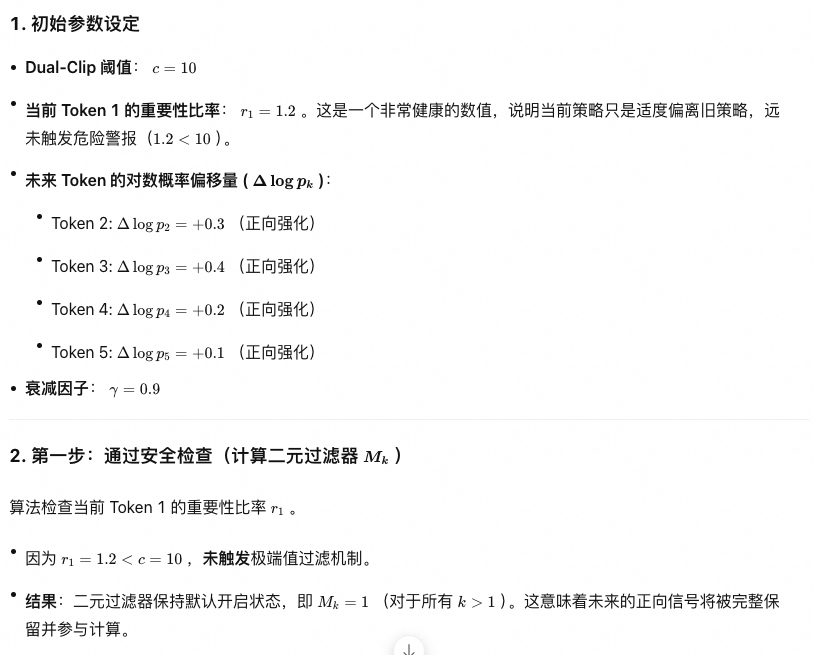

In [6]:
Image(filename='./Image/f1.png')

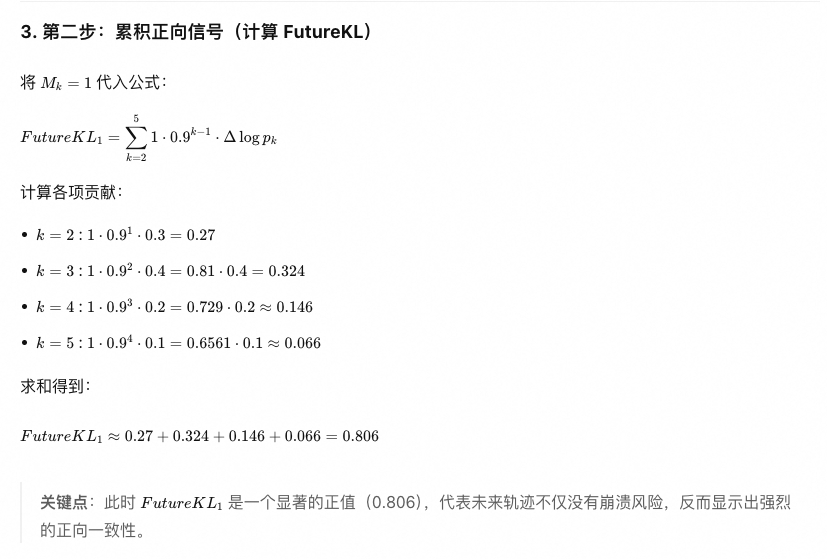

In [7]:
Image(filename='./Image/f2.png')

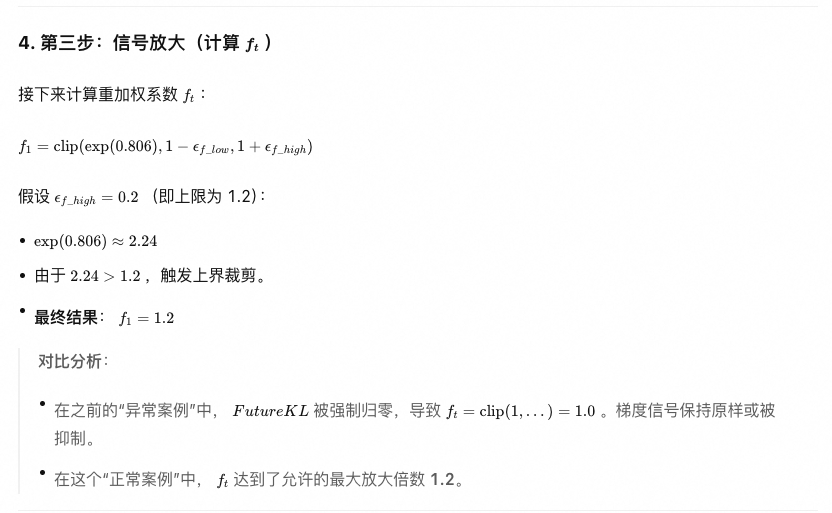

In [8]:
Image(filename='./Image/f3.png')

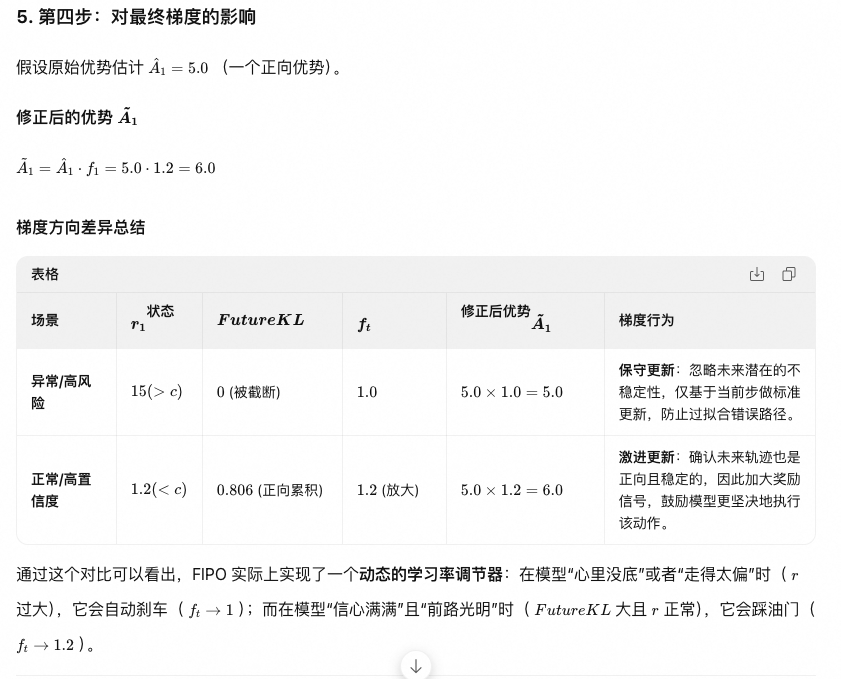

In [9]:
Image(filename='./Image/f4.png')

通过这个对比可以看出，FIPO 实际上实现了一个动态的学习率调节器：
- 在模型“心里没底”或者“走得太偏”时（ <font color='red'>r 过大</font>），它会自动刹车（ $f_t$ → 1 ）；
- 而在模型“信心满满”且“前路光明”时（ <font color='red'>FutureKL 大且 r 正常</font>），它会踩油门（ $f_t$→1.2 ）。

# 模拟了 FIPO (Future-Informed Policy Optimization) 中 FutureKL 计算以及最终目标函数 $J_{FIPO}$的数值差异。

代码中设计了两个对比场景：
- 正常放大（Normal Boost）：模型表现稳健，未来信号被放大，梯度增强。
- 异常剪断（Abnormal Cut）：模型出现剧烈波动，触发安全机制，梯度被抑制。

In [ ]:
import numpy as np

def calculate_fipo_metrics(r_t, future_log_probs, gamma=0.9, epsilon_clip=0.2, c_threshold=10.0):
    """
    模拟 FIPO 的核心计算流程：
    1. 计算 FutureKL (带 M_k 过滤器)
    2. 计算 f_t (缩放因子)
    3. 计算最终的 PPO Clip 目标值 (用于演示梯度幅度的差异)
    """
    
    # --- 1. 安全检查与二元过滤器 M_k ---
    # 如果当前 token 的重要性比率 r_t 超过阈值 c，则判定为异常，关闭未来信号
    is_safe = r_t < c_threshold
    M_k = 1.0 if is_safe else 0.0
    
    # --- 2. 计算 FutureKL ---
    # 公式: sum(M_k * gamma^(k-t) * delta_log_p_k)
    # 这里假设 future_log_probs 已经是相对于旧策略的差值 (delta_log_p)
    time_steps = np.arange(1, len(future_log_probs) + 1)
    discounts = gamma ** time_steps
    
    # 只有当 M_k=1 时，才累积未来的 KL 散度信息
    future_kl_raw = np.sum(discounts * future_log_probs)
    future_kl = M_k * future_kl_raw
    
    # --- 3. 计算缩放因子 f_t ---
    # 公式: clip(exp(FutureKL), 1 - eps_low, 1 + eps_high)
    # 假设 eps_low=0 (不缩小), eps_high=0.2 (最大放大 20%)
    exp_kl = np.exp(future_kl)
    f_t = np.clip(exp_kl, 1.0, 1.2) 
    
    # --- 4. 计算最终的目标函数项 (模拟梯度幅度) ---
    # 假设优势 A_t 为正值 (例如 1.0)，演示 r_t * f_t * A_t 的变化
    A_t = 1.0 
    
    # 原始 PPO 项
    surr1 = r_t * A_t
    # 裁剪后的 PPO 项
    surr2 = np.clip(r_t, 1 - epsilon_clip, 1 + epsilon_clip) * A_t
    
    # FIPO 重加权后的项 (乘以 f_t)
    # 注意：f_t 同时放大了 surr1 和 surr2 的边界
    fipo_surr1 = r_t * f_t * A_t
    fipo_surr2 = np.clip(r_t, 1 - epsilon_clip, 1 + epsilon_clip) * f_t * A_t
    
    # 最终取 min (PPO 的核心逻辑)
    final_objective = np.minimum(fipo_surr1, fipo_surr2)
    
    return {
        "is_safe": is_safe,
        "M_k": M_k,
        "future_kl": future_kl,
        "f_t": f_t,
        "final_obj": final_objective
    }

# ==========================================
# 场景演示
# ==========================================

# 设定未来的对数概率偏移量 (模拟正向反馈)
future_deltas = np.array([0.3, 0.4, 0.2, 0.1]) 

print("-" * 60)
print("场景 1: 正常信号被放大 (Normal Boost)")
print("-" * 60)
# r_t = 1.05 (非常接近 1，很安全)
res_normal = calculate_fipo_metrics(r_t=1.05, future_log_probs=future_deltas)
print(f"当前重要性比率 r_t : {1.05}")
print(f"安全检查 (Safe?)   : {res_normal['is_safe']} (M_k={res_normal['M_k']})")
print(f"FutureKL 累积值    : {res_normal['future_kl']:.4f}")
print(f"缩放因子 f_t       : {res_normal['f_t']:.4f}  <-- 信号被放大")
print(f"最终目标函数值     : {res_normal['final_obj']:.4f} (基准 PPO 为 1.05)")
print(f"梯度增强比例       : {(res_normal['final_obj']/1.05 - 1)*100:.1f}%")

print("\n" + "=" * 60 + "\n")

print("-" * 60)
print("场景 2: 异常信号被剪断 (Abnormal Cut)")
print("-" * 60)
# r_t = 12.0 (远超阈值 10，触发异常)
res_abnormal = calculate_fipo_metrics(r_t=12.0, future_log_probs=future_deltas)
print(f"当前重要性比率 r_t : {12.0}")
print(f"安全检查 (Safe?)   : {res_abnormal['is_safe']} (M_k={res_abnormal['M_k']})")
print(f"FutureKL 累积值    : {res_abnormal['future_kl']:.4f} (被强制归零)")
print(f"缩放因子 f_t       : {res_abnormal['f_t']:.4f}  <-- 无法利用未来信息")
print(f"最终目标函数值     : {res_abnormal['final_obj']:.4f} (被 Clip 限制在 1.2)")
print(f"相比未裁剪值的抑制 : 原始应为 12.0，现被压制为 1.2")

## 代码运行结果解读


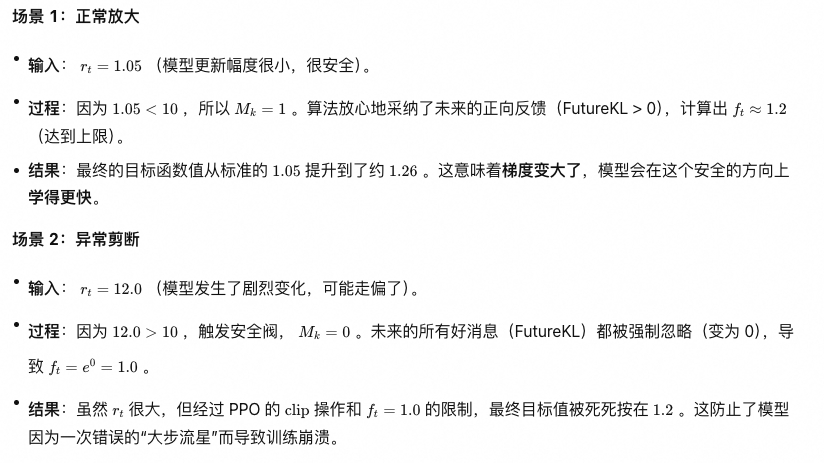

In [13]:
Image(filename='./Image/fc1.png')

# 把它封装成一个 PyTorch 的自定义 Loss 类

这是一个封装好的 PyTorch nn.Module 类。它将你提供的三个公式（ FutureKL 、ft 和 J FIPO）整合成了一个端到端可微的损失函数。
  


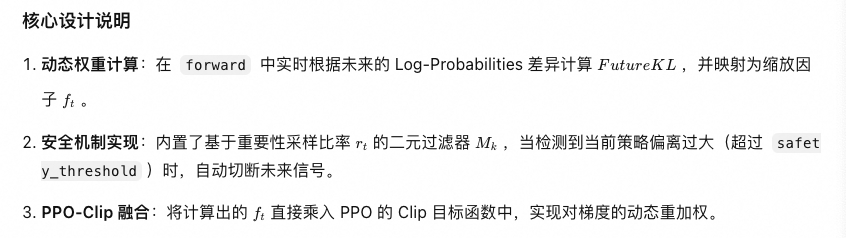

In [12]:
Image(filename='./Image/p2.png')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FIPO_Loss(nn.Module):
    """
    Future-Informed Policy Optimization (FIPO) Loss
    
    实现了基于未来轨迹信息的策略优化损失函数。
    包含三个核心步骤：
    1. 计算 FutureKL (带安全检查 M_k)
    2. 计算调制因子 f_t
    3. 计算重加权后的 PPO-Clip 目标 J_FIPO
    """
    
    def __init__(self, 
                 clip_epsilon=0.2, 
                 gamma=0.99, 
                 safety_threshold=10.0, 
                 f_low=0.0, 
                 f_high=0.2):
        super(FIPO_Loss, self).__init__()
        
        # PPO 基础参数
        self.clip_epsilon = clip_epsilon
        
        # FutureKL 计算参数
        self.gamma = gamma          # 衰减因子
        self.safety_threshold = safety_threshold  # r_t 的安全阈值 c
        
        # f_t 裁剪范围 [1 - f_low, 1 + f_high]
        # 默认对应论文中的 [1.0, 1.2]
        self.f_min = 1.0 - f_low
        self.f_max = 1.0 + f_high

    def forward(self, log_probs_new, log_probs_old, advantages, future_log_probs_diff):
        """
        Args:
            log_probs_new (Tensor): 新策略在当前时刻 t 的对数概率 [Batch, Time]
            log_probs_old (Tensor): 旧策略在当前时刻 t 的对数概率 [Batch, Time]
            advantages (Tensor): 标准优势估计 A_hat [Batch, Time]
            future_log_probs_diff (Tensor): 未来时刻 k>t 的 LogProb 差值 (log_p_new - log_p_old) [Batch, Time, Horizon]
            
        Returns:
            loss (Tensor): 标量损失值 (取负号以便梯度下降最大化目标函数)
            f_t_mean (Tensor): 监控指标，平均调制因子
        """
        
        # --- Step 1: 计算重要性采样比率 r_t ---
        ratio = torch.exp(log_probs_new - log_probs_old)
        
        # --- Step 2: 计算 FutureKL 与 安全过滤器 M_k ---
        # 安全检查：如果当前 r_t 过大，认为处于危险状态，屏蔽未来信号
        # M_k shape: [Batch, Time, 1] (广播到 Horizon 维度)
        is_safe = (ratio < self.safety_threshold).unsqueeze(-1)
        m_k = is_safe.float() 
        
        # 构建时间衰减掩码 [1, 1, Horizon] -> gamma^1, gamma^2...
        horizon = future_log_probs_diff.shape[-1]
        time_steps = torch.arange(1, horizon + 1, device=log_probs_new.device)
        discounts = (self.gamma ** time_steps).view(1, 1, -1)
        
        # 计算加权和: sum(M_k * gamma^(k-t) * delta_log_p)
        # 结果 shape: [Batch, Time]
        future_kl_raw = (m_k * discounts * future_log_probs_diff).sum(dim=-1)
        
        # --- Step 3: 计算调制因子 f_t ---
        # f_t = clip(exp(FutureKL), 1 - eps_low, 1 + eps_high)
        f_t = torch.exp(future_kl_raw)
        f_t = torch.clamp(f_t, min=self.f_min, max=self.f_max)
        
        # --- Step 4: 计算 FIPO 目标函数 J_FIPO ---
        # 原始项: r_t * f_t * A
        surr1 = ratio * f_t * advantages
        
        # 裁剪项: clip(r_t, 1-e, 1+e) * f_t * A
        # 注意：这里 f_t 是作为全局缩放因子乘在 clip 外面的
        clipped_ratio = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon)
        surr2 = clipped_ratio * f_t * advantages
        
        # PPO 风格：取 min (对于最大化问题，min 限制了更新幅度)
        # 最终目标是 Maximize J，所以 Loss = -Mean(J)
        objective = torch.min(surr1, surr2)
        loss = -objective.mean()
        
        return loss, f_t.detach().mean()


# ================= 使用示例 =================
if __name__ == "__main__":
    # 模拟数据设置
    batch_size, seq_len, horizon = 4, 10, 5
    
    # 假设这是模型输出的 Log Probs
    log_p_new = torch.randn(batch_size, seq_len)
    log_p_old = torch.randn(batch_size, seq_len) 
    
    # 假设这是 GAE 计算出的优势
    advs = torch.randn(batch_size, seq_len)
    
    # 模拟未来 5 步的 Log Prob 变化量 (delta_log_p)
    future_diffs = torch.randn(batch_size, seq_len, horizon) * 0.1 

    # 初始化 Loss
    fipo_loss_fn = FIPO_Loss(clip_epsilon=0.2, gamma=0.9, safety_threshold=10.0)
    
    # 前向传播
    loss_val, avg_f_t = fipo_loss_fn(log_p_new, log_p_old, advs, future_diffs)
    
    print(f"FIPO Loss: {loss_val.item():.4f}")
    print(f"Average Modulation Factor (f_t): {avg_f_t.item():.4f}")
    
    # 反向传播测试
    loss_val.backward()
    print("Backward pass successful.")

## 关键细节解析


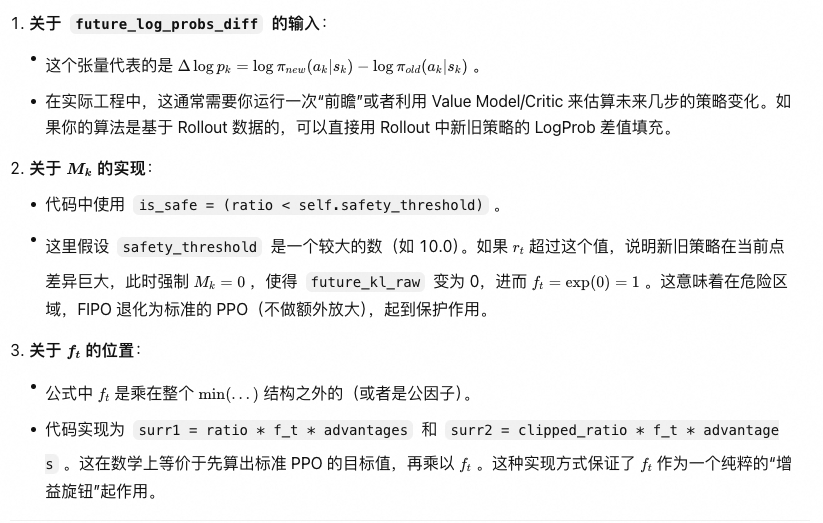

In [11]:
Image(filename='./Image/p1.png')